In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [2]:
import pandas as pd

titanic = pd.read_csv("seaborn_titanic.csv")
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
titanic.shape

(891, 15)

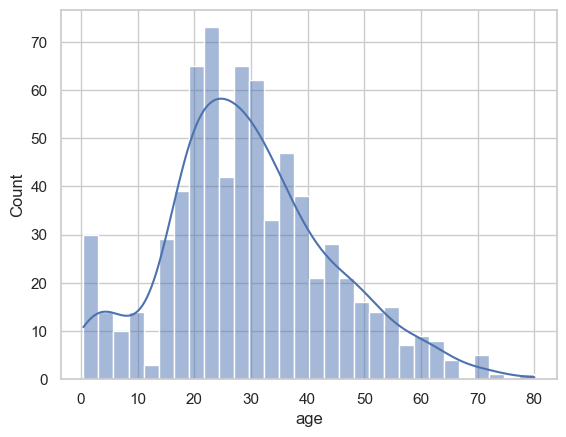

In [4]:
sns.histplot(titanic["age"], bins=30, kde=True)
plt.show()

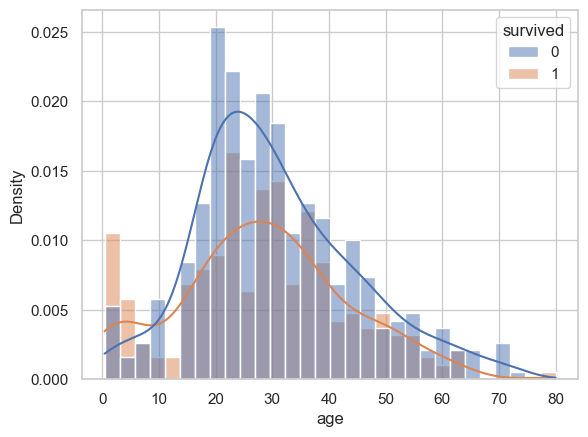

In [5]:
# kde는 Kernel Density Estimation(커널 밀도 추정) 입니다.
# 히스토그램 막대를 매끄러운 곡선으로 표현해서 분포 형태를 보기 쉽게 해줘요.

# 히스토그램: 구간(bin)별 막대
# KDE: 확률밀도 곡선(부드러운 분포선)
sns.histplot(
    data=titanic,
    x="age",
    hue="survived",
    bins=30,
    kde=True,
    stat="density",
)
plt.show()

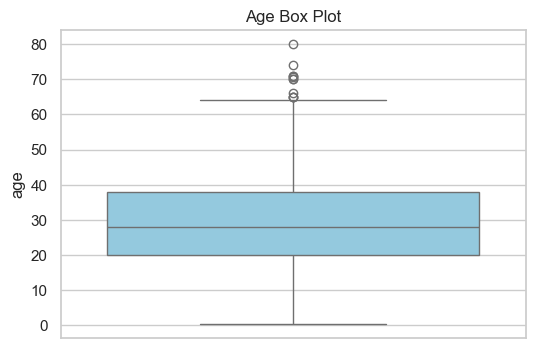

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(data=titanic, y="age", ax=ax, color="skyblue")
ax.set_title("Age Box Plot")
plt.show()

/var/folders/6r/ryg35lj50jg7mx0b5gtcd61c0000gn/T/ipykernel_66282/2397442494.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=titanic, x="sex", ax=ax, palette="pastel")


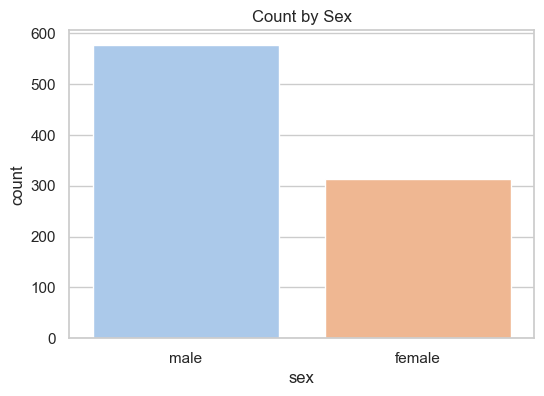

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=titanic, x="sex", ax=ax, palette="pastel")
ax.set_title("Count by Sex")
plt.show()

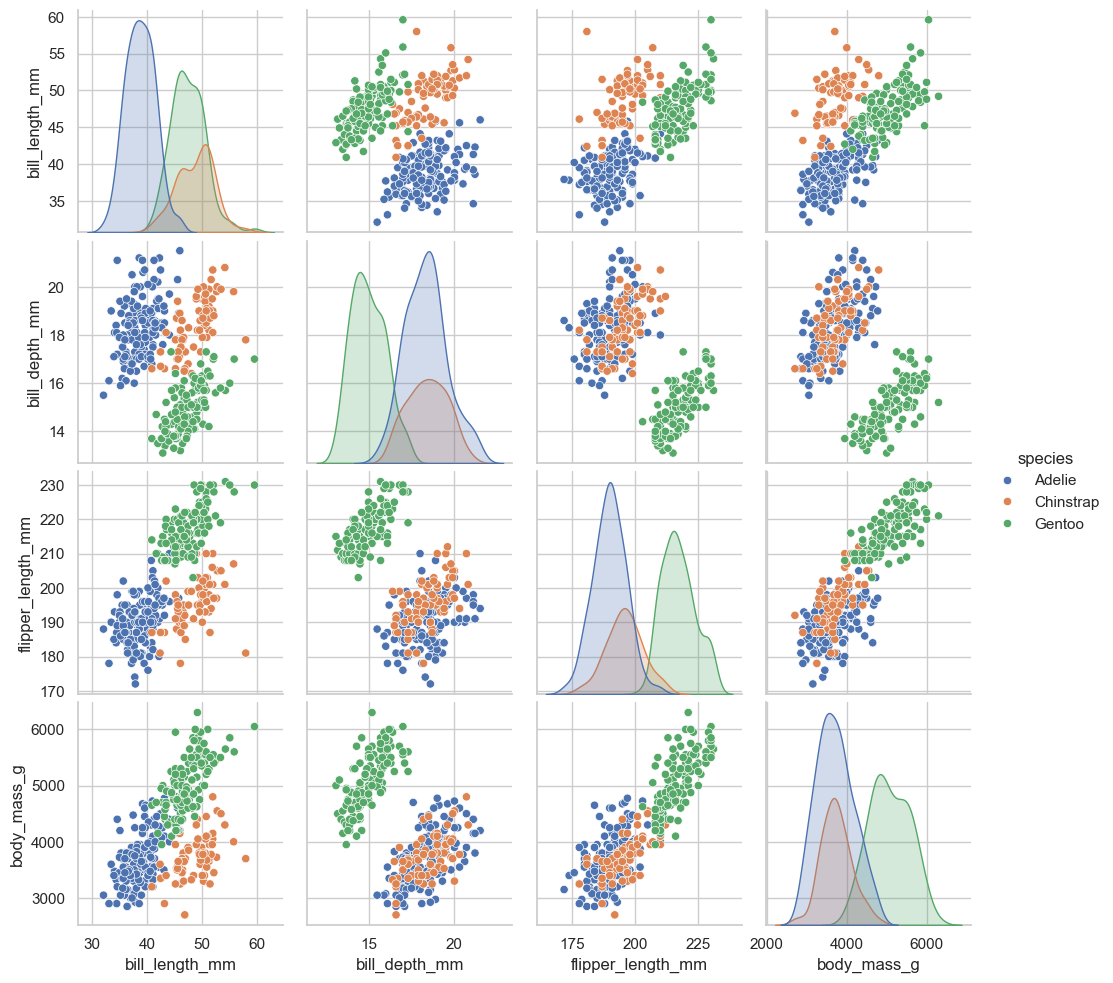

In [8]:
penguins = pd.read_csv("seaborn_penguins.csv")
sns.pairplot(data=penguins, hue="species")

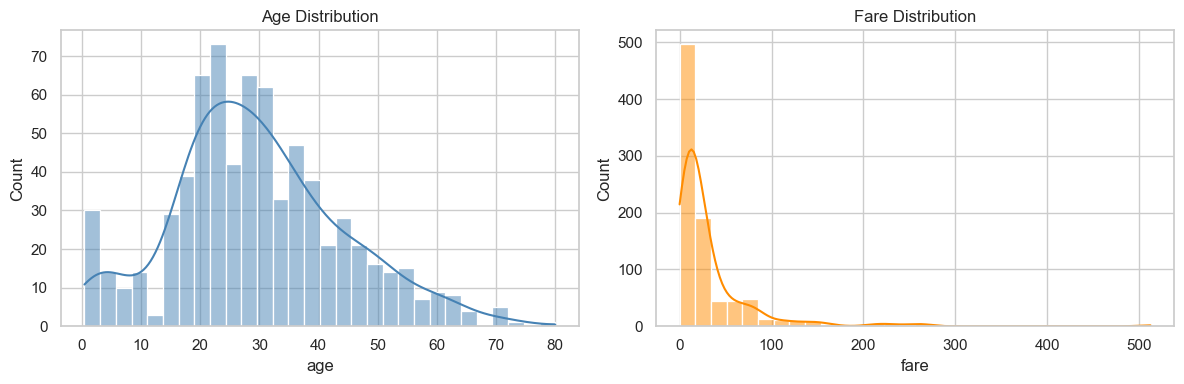

/var/folders/6r/ryg35lj50jg7mx0b5gtcd61c0000gn/T/ipykernel_66282/1911079607.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=titanic, x="pclass", y="fare", ax=axes[1], palette="Set2")


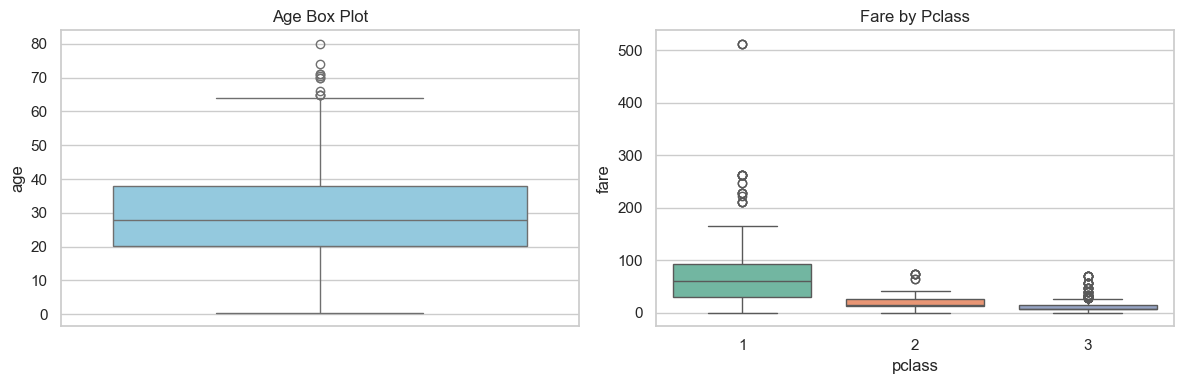

/var/folders/6r/ryg35lj50jg7mx0b5gtcd61c0000gn/T/ipykernel_66282/1911079607.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=titanic, x="sex", ax=axes[0], palette="pastel")
/var/folders/6r/ryg35lj50jg7mx0b5gtcd61c0000gn/T/ipykernel_66282/1911079607.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=titanic, x="embarked", ax=axes[1], palette="muted")


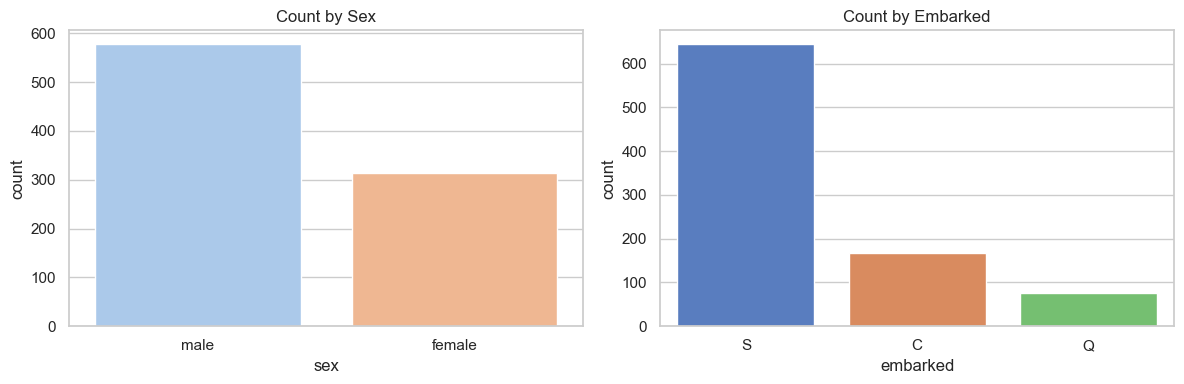

In [9]:
# -------------------------
# 단변량 분석
# -------------------------

# 1) Histogram: age, fare 분포
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(titanic["age"], kde=True, bins=30, ax=axes[0], color="steelblue")
axes[0].set_title("Age Distribution")

sns.histplot(titanic["fare"], kde=True, bins=30, ax=axes[1], color="darkorange")
axes[1].set_title("Fare Distribution")
plt.tight_layout()
plt.show()

# 2) Box Plot: 중앙값/사분위/이상치 확인
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=titanic, y="age", ax=axes[0], color="skyblue")
axes[0].set_title("Age Box Plot")

sns.boxplot(data=titanic, x="pclass", y="fare", ax=axes[1], palette="Set2")
axes[1].set_title("Fare by Pclass")
plt.tight_layout()
plt.show()

# 3) Count Plot: 범주형 변수 빈도
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=titanic, x="sex", ax=axes[0], palette="pastel")
axes[0].set_title("Count by Sex")

sns.countplot(data=titanic, x="embarked", ax=axes[1], palette="muted")
axes[1].set_title("Count by Embarked")
plt.tight_layout()
plt.show()

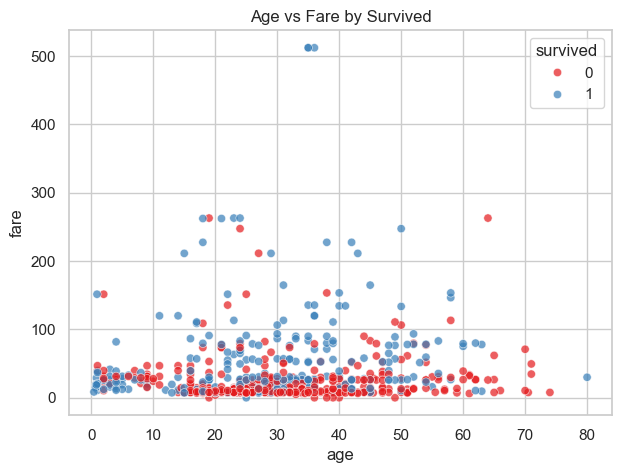

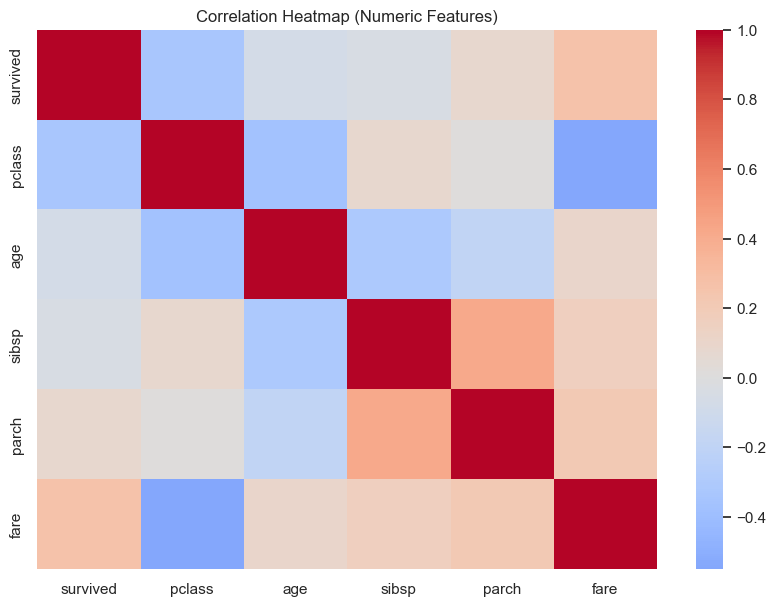

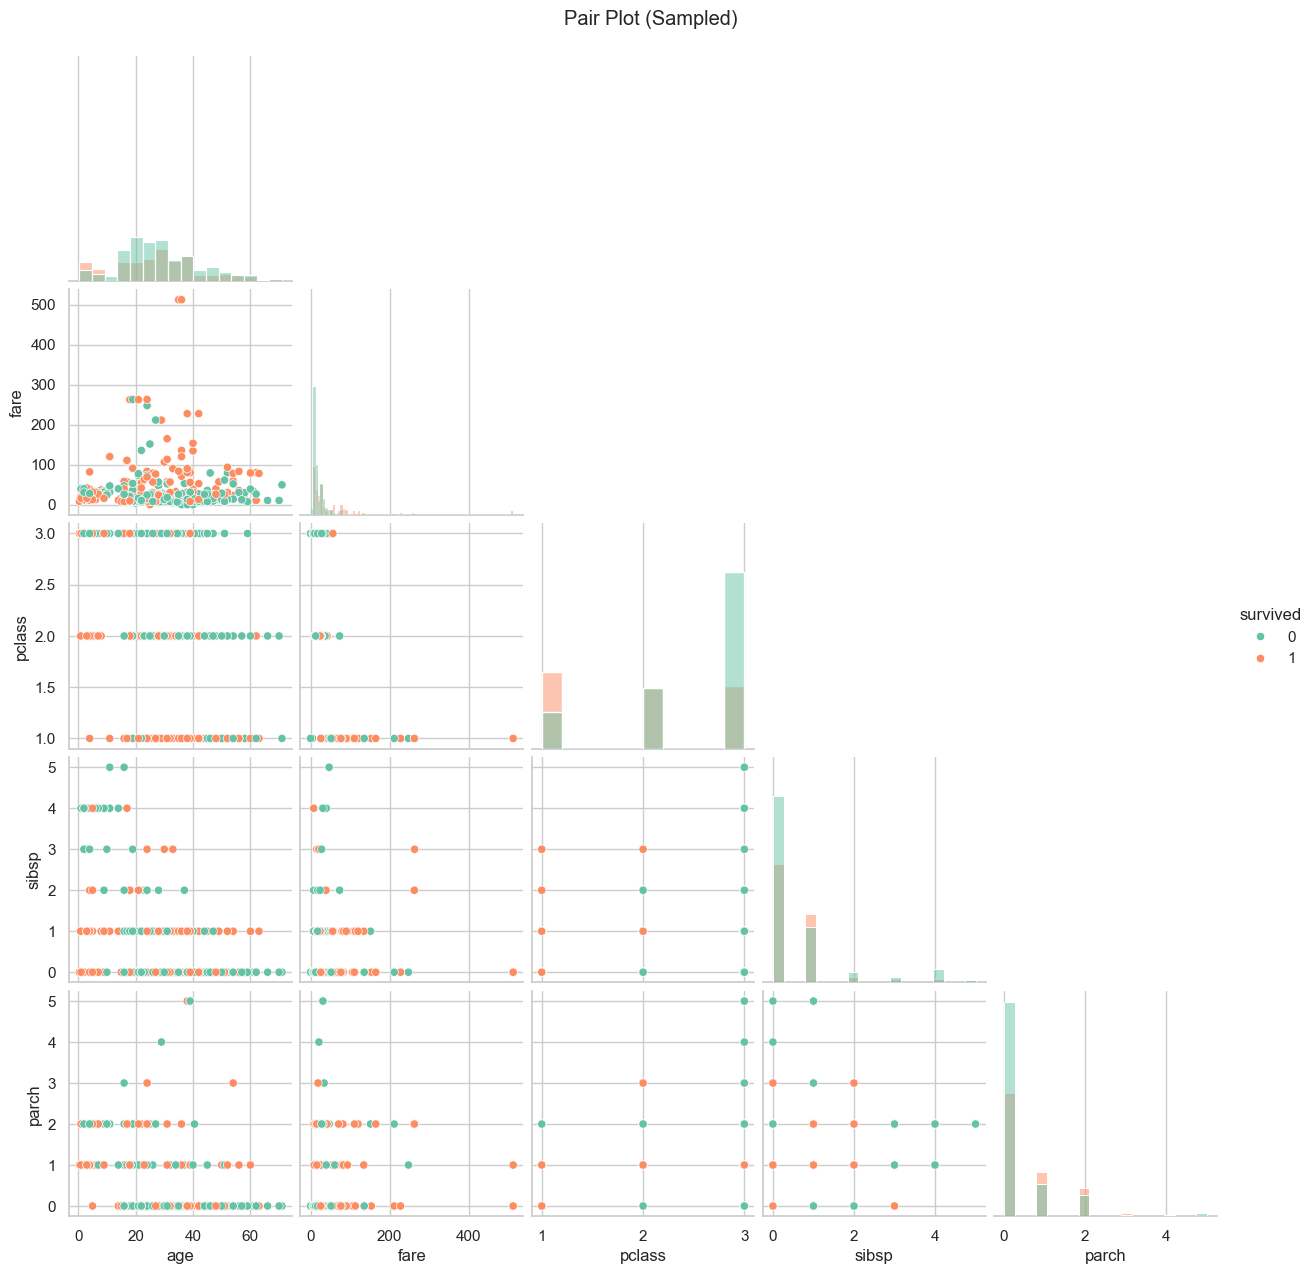

In [10]:
# -------------------------
# 다변량 분석
# -------------------------

# 1) Scatter Plot: 두 변수 관계 + 생존 여부 색상 구분
plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=titanic,
    x="age",
    y="fare",
    hue="survived",
    alpha=0.7,
    palette="Set1"
)
plt.title("Age vs Fare by Survived")
plt.show()

# 2) Heatmap: 수치형 변수 상관행렬
num_df = titanic.select_dtypes(include=["number"]).copy()
plt.figure(figsize=(10, 7))
sns.heatmap(num_df.corr(), cmap="coolwarm", center=0, annot=False)
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()

# 3) Pair Plot: 주요 변수 조합 산점도
pair_cols = ["survived", "age", "fare", "pclass", "sibsp", "parch"]
pair_df = titanic[pair_cols].dropna().copy()

# 너무 무거워질 수 있어 샘플링
if len(pair_df) > 400:
    pair_df = pair_df.sample(400, random_state=42)

sns.pairplot(pair_df, hue="survived", corner=True, diag_kind="hist", palette="Set2")
plt.suptitle("Pair Plot (Sampled)", y=1.02)
plt.show()